# Variáveis linguísticas de saída e de entrada segundo enunciado

Os valores de entrada são:
1. **Índice de massa corpórea (IMC)**
2. **Glicose no sangue (glicemia de jejum)**
3. **Colesterol total.**

Como saída:
- **risco de doença cardíacas**


Essas 4 variáveis (3 entradas e 1 saída) são as variáveis linguísticas. Use uma tabela para mapear as regras indicados conjuntos fuzzy dos antecedentes e consequentes das regras (não deixe de incluir no relatório). Defina um número de conjuntos fuzzy e seus formatos que considere adequados para determinar os riscos associados.

OBS: Podem ser usados 3 tipos de funções de pertinência: **triangular**, **gaussiana** e função de **trapezoidal**.

---
# Interpretando Artigos, criando regras e conjuntos

## Obesidade X Doença cardiovascular

### Informação para os conjuntos conforme em [SBCBM - obesidade](https://sbcbm.org.br/obesidade-atinge-mais-de-67-milhoes-de-pessoas-no-brasil-em-2022/)


- **Peso ideal**: $18.5 <= IMC <= 24.9$
- **Sobrepeso: $IMC > 25 Kg/m²$**

- **Obesidade se o IMC for maior ou igual a 30 Kg/m2.** A classificação da obesidade é feita da seguinte forma:
  - **Grau I:  $30 <= IMC <= 34,9$**;
  - **Grau II: $35 <= IMC <= 39,9$**;
  - **Grau III: (obesidade mórbida): $IMC >= 40$**.

###Informação para as regras

#### Segundo fonte [SBCBM - obesidade](https://sbcbm.org.br/obesidade-atinge-mais-de-67-milhoes-de-pessoas-no-brasil-em-2022/)

"**Indicação**

Os critérios previstos nas portarias 424 e 425 do Ministério da Saúde para realização da cirurgia bariátrica pelo SUS são Índice de Massa Corporal (IMC) de 40 Kg/m², com ou sem comorbidades, sem sucesso no tratamento clínico por no mínimo dois anos e que tenham seguido protocolos clínicos.

As portarias também permitem a indicação para cirurgia bariátrica de pacientes com IMC > 35 kg/m2 e comorbidades com alto risco cardiovascular, diabetes e/ou hipertensão arterial de difícil controle, apneia do sono, doenças articulares degenerativas ou outras que não tenham tido sucesso no tratamento clínico."

"As portarias também permitem a indicação para cirurgia bariátrica de pacientes com IMC > 35 kg/m² e comorbidades com alto risco cardiovascular,"

#### Segundo fonte [world-health-organization](https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight?utm_source=chatgpt.com)

"Being overweight in childhood and adolescence affects children’s and adolescents’ immediate health and is associated with greater risk and earlier onset of various NCDs, such as type 2 diabetes and cardiovascular disease."

#### Segundo fonte [jamacardiology-fullarticle](https://jamanetwork.com/journals/jamacardiology/fullarticle/2673289?utm_source=chatgpt.com)

"Compared with normal weight, among middle-aged men and women, competing hazard ratios for incident CVD were 1.21 (95% CI, 1.14-1.28) and 1.32 (95% CI, 1.24-1.40), respectively, for overweight (BMI, 25.0-29.9), 1.67 (95% CI, 1.55-1.79) and 1.85 (95% CI, 1.72-1.99) for obesity (BMI, 30.0-39.9), and 3.14 (95% CI, 2.48-3.97) and 2.53 (95% CI, 2.20-2.91) for morbid obesity (BMI, ≥40.0). Higher BMI had the strongest association with incident heart failure among CVD subtypes."

Há uma progressão quase “monótona” do risco de problemas cardiácos conforme subimos de normal → sobrepeso → obesidade → obesidade mórbida.

#### Criando as regras iniciais conforme os artigos

Como não incluímos algo como: idade ou outras comorbidades que afetem o quesito de doença cardiovascular o que poderia ajudar bastante segundo os 2 artigos, podemos já iniciar regras para o sistema Fuzzy. Essas regras serão depois modificadas ou aglomeradas com as regras das outras 2 variáveis com operadores de E/OU:

- Peso ideal → risco Baixo/Médio
- Sobrepeso → risco Médio
- Obesidade Grau I → risco Alto
- Obesidade Grau II → risco Muito_Alto
- Obesidade Grau III → risco Extremo

## Glicemia de jejum X Doença cardiovascular

### Conjunto fuzzy


- ~**Hipoglicemia:** A presença de glicemia de jejum < 70~
- **Normal:** Glicemia de jejum entre $(70<=G<=99)\ mg/dL$;
- **Pré-diebete:** Glicemia de jejum entre $(100 <= G <= 125)\ mg/dL$;
- **Diabete_moderada:** Glicemia de jejum $(126 <= G <= 180)mg/dL$
- **Diabetes_muito_alta:** Glicemia de jejum $ (180 <= G <= 200)mg/dL$

No presente modelo fuzzy, as entradas são apenas IMC, glicemia de jejum e colesterol total. Não há informações sobre diagnóstico de diabetes, tipo de tratamento, função hepática ou renal, frequência de episódios hipoglicêmicos ou outras doenças de base. Nessas condições, a simples presença de glicemia < 70 mg/dL em jejum é ambígua e poderia levar a uma inferência errada de risco cardiovascular. Por esse motivo, optou-se por excluir a faixa de hipoglicemia do universo de discurso da glicemia, limitando o modelo ao intervalo de 70 a 200 mg/dL, focado na hiperglicemia crônica (pré-diabetes e diabetes), que é um fator bem estabelecido de risco cardiovascular.

Em um sistema mais completo, que incorporasse o manejo da hipoglicemia como fator de risco cardiovascular, seria necessário incluir variáveis adicionais, tais como: diagnóstico e tempo de diabetes, função hepática e renal, histórico de episódios de hipoglicemia grave, uso de álcool e estado nutricional. Só com esse conjunto de informações seria possível construir uma base de regras fuzzy capaz de interpretar adequadamente a hipoglicemia no contexto do risco cardiovascular global.

### Regras (somente glicemia - depois irei unir)

* SE glicemia em jejum é Normal
ENTÃO contribuição_da_glicemia_para_risco_DCV é Baixa
  - A categoria de referência (baseline). Mesmo assim, o risco total pode subir por IMC, colesterol, mas pelo eixo glicemia você não adiciona muito.

<br>

* SE glicemia em jejum é Alterada (pré-diabetes)
ENTÃO contribuição_da_glicemia_para_risco_DCV é Moderada
  - Aumento de ~15% no risco de DCV vs normoglicemia, o que é claramente maior que zero, mas bem menor que o efeito do diabetes.

<br>

* SE glicemia em jejum é Diabete moderada
ENTÃO contribuição_da_glicemia_para_risco_DCV é Alto
  - diabetes dobra ou até quadruplica o risco de DCV e é um dos principais fatores de risco modificáveis.

<br>

* SE glicemia em jejum é Diabete muito_alta
ENTÃO contribuição_da_glicemia_para_risco_DCV é muito alta




#### Referências (além das recomendadas no trabalho) para esse tópico

https://diabetesjournals.org/care/article/47/Supplement_1/S20/153954/2-Diagnosis-and-Classification-of-Diabetes?utm_source=chatgpt.com

https://www.tuasaude.com/glicemia-de-jejum/

http://nav.dasa.com.br/blog/tudo-sobre-diabetes

## Colesterol total X Doença cardiovascular

Como a descrição sobre os níveis de colesterol no nav dasa não estava muito completo, utilizei uma fonte americana:

[Cholesterol, Total, Serum](https://pediatric.testcatalog.org/show/CHOL) que diz sobre o conjuntos que podemos criar para o colesterol:

"Interpretation
The National Lipid Association and the National Cholesterol Education Program (NCEP) have set the following guidelines for total cholesterol:



Desirable: $<200 mg/dL$

Borderline High: $200\ to\ 239 mg/dL$

High: $ ≥ 240 mg/dL$"

Para o colesterol total, os conjuntos fuzzy foram definidos a partir dos pontos de corte recomendados por diretrizes internacionais e nacionais.

As diretrizes do National Cholesterol Education Program (NCEP ATP III) e da National Lipid Association classificam o colesterol total em desejável (<200 mg/dL), limítrofe (200–239 mg/dL) e alto (≥240 mg/dL).


No Brasil, a Atualização da Diretriz Brasileira de Dislipidemias e Prevenção da Aterosclerose e documentos derivados da Sociedade Brasileira de Cardiologia tornaram as metas mais rígidas, considerando valores desejáveis de colesterol total abaixo de 190 mg/dL como dito no navdasa.


Neste trabalho, utilizarei esses limiares como base para a construção dos conjuntos fuzzy, ajustando o valor desejável para 190 mg/dL a fim de alinhar o modelo ao contexto brasileiro.

Ou seja definimos o conjunto:

- **Desejável:** $C < 190 mg/dL$
- **limítrofe:** $(190 <= C <= 239)mg/dL$
- **Alto:** $C >= 240mg/dL$

como o definido:
"O colesterol alto está associado a um maior risco de problemas cardiovasculares." no [nav-data-colesterol-total](https://nav.dasa.com.br/blog/colesterol-total#Valores_de_referencia_de_colesterol_total) usamos a regra:

SE colesterol é alto então muito alta chance de doença cardiovasculares

## Risco de doença cardiovascular

Analisando as outras variáveis linguísticas de entrada, percebi que em geral temos uma relação direta entre cada uma delas e a saída, por mais que não seja linear, existe uma relação de crescimento. E em geral temos 5 graus.

<br>

por exemplo hipoglicemia, ideal, pre diabético, diabético moderado e diabético alto. Onde eu tiro a hipoglicemia, pois ela está mais associada à outros tipos de comorbidades (por exemplo problemas nos rins) do que o risco de doença cardiovascular e percebi que seria basicamente ter outra coluna "ideal", logo tirei ela.

<br>

Outro exemplo é o IMC:
Peso ideal, sobrepeso, obesidade grau 1, 2 e 3.

Logo, por as variáveis de entrada serem associadas diretamente ao risco, criei 5 graus de risco:

- Baixo risco;
- Médio risco;
- Alto risco;
- Risco muito alto;
- Risco extremo (a pessoa aqui provavelmente já tem problemas cardiácos)

---
# Criando as tabelas

Para a criação das tabelas estou considerando as informações tiradas das referências que em geral são artigos, por exemplo sabemos que Obesidade tem uma relação direta com doença cardíaca segundo [jamacardiology-fullarticle](https://jamanetwork.com/journals/jamacardiology/fullarticle/2673289?utm_source=chatgpt.com), então podemos dizer por exemplo que sobrepeso é risco médio. Mas em conjunto com as informações independentes, tentarei criar uma conexão entre as outras variáveis de entrada.

Por exemplo:

Sobrepeso e diabete alta podemos já relacionar com um risco alto. Mesmo que sobrepeso seja teria uma relação mais próxima a risco médio, diabete alta é risco extremo então digo que é chance alta (perceba que muito alta também seria válido).

#### Legenda para interpretação das tabelas

**IMC:**
- PI = Peso ideal
- SP = Sobrepeso
- O1 = Obesidade grau 1
- O2 = Obesidade grau 2
- O3 = Obesidade grau 3


**Risco de doença cardiovascular (saída):**
- B = Risco baixo
- M = Risco médio
- A = Risco Alto
- MA = Risco m

**Glicemia:**
- N = Normal
- PRE = Pre diabete
- DM1 = Diabete moderada
- DM2 = Diabete Alta

## Tabela 1 – Colesterol Desejável (CD)

#### Risco quando C < 190 mg/dL:

| IMC \ Glicemia | N | PRE | DM1 | DM2 |
| -------------- | - | --- | --- | --- |
| **PI**         | B | B   | M   | M   |
| **SP**         | B | M   | M   | A   |
| **O1**         | M | M   | A   | A   |
| **O2**         | M | A   | A   | MA  |
| **O3**         | A | MA   | MA  | E   |


## Tabela 2 – Colesterol Limítrofe (CL)

#### Risco quando 190 ≤ C ≤ 239 mg/dL:

| IMC \ Glicemia | N  | PRE | DM1 | DM2 |
| -------------- | -- | --- | --- | --- |
| **PI**         | B  | M   | M   | A   |
| **SP**         | M  | M   | A   | MA  |
| **O1**         | M  | A   | MA  | MA  |
| **O2**         | A  | MA  | MA  | E   |
| **O3**         | MA | MA  | E   | E   |


## Tabela 3 – Colesterol Alto (CA)
Risco quando C ≥ 240 mg/dL:

| IMC \ Glicemia | N  | PRE | DM1 | DM2 |
| -------------- | -- | --- | --- | --- |
| **PI**         | M  | M   | A   | MA  |
| **SP**         | M  | A   | MA  | MA  |
| **O1**         | A  | MA  | MA  | E   |
| **O2**         | MA | MA  | E   | E   |
| **O3**         | MA | E   | E   | E   |


---
# Código

In [6]:
!pip install -U scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 20.3 MB/s eta 0:00:00


## Montando o conjunto de Saída (risco de doença cardiovascular)

In [7]:
import skfuzzy as fuzz

In [8]:
import numpy as np

x_risco = np.linspace(0, 100, 1001)

baixo       = fuzz.gaussmf(x_risco, 10, 8)
medio       = fuzz.gaussmf(x_risco, 30, 8)
alto        = fuzz.gaussmf(x_risco, 50, 8)
muito_alto  = fuzz.gaussmf(x_risco, 70, 8)
extremo     = fuzz.smf(x_risco, 80, 90)  # sobe entre 80 e 90 e fica 1 daí pra frente


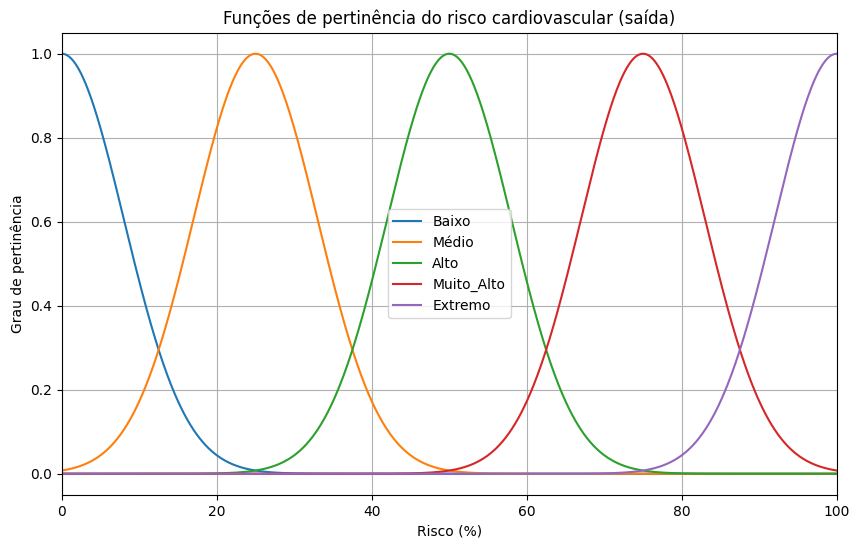

In [9]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# Universo do risco (0 a 100%)
x_risco = np.linspace(0, 100, 1001)

# Mesmo sigma para todos
sigma = 8.0  # pode ajustar depois se quiser mais "larga" ou mais "estreita"

# Centros das gaussianas
c_baixo      = 0
c_medio      = 25
c_alto       = 50
c_muito_alto = 75
c_extremo    = 100

# Funções de pertinência (Baixo e Extremo viram "meia gaussiana" no intervalo 0–100)
baixo       = fuzz.gaussmf(x_risco, c_baixo,      sigma)
medio       = fuzz.gaussmf(x_risco, c_medio,      sigma)
alto        = fuzz.gaussmf(x_risco, c_alto,       sigma)
muito_alto  = fuzz.gaussmf(x_risco, c_muito_alto, sigma)
extremo     = fuzz.gaussmf(x_risco, c_extremo,    sigma)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x_risco, baixo,      label='Baixo')
plt.plot(x_risco, medio,      label='Médio')
plt.plot(x_risco, alto,       label='Alto')
plt.plot(x_risco, muito_alto, label='Muito_Alto')
plt.plot(x_risco, extremo,    label='Extremo')

plt.title('Funções de pertinência do risco cardiovascular (saída)')
plt.xlabel('Risco (%)')
plt.ylabel('Grau de pertinência')
plt.ylim(-0.05, 1.05)
plt.xlim(0, 100)
plt.grid(True)
plt.legend()
plt.show()


## Montando Conjuntos das variáveis linguísticas de entrada

Nas variáveis linguísticas percebi que temos 2 escolhas de gráfico usando gaussiana.

1. **Utilizar "platô" na classe mais extrema à direita.**
Ou seja, quando a gaussiana dessa classe chegar no ápice, utilizar: $µ(x) = 1.0$

2. **Utilizar a gaussiana natural:** Ou seja, a gaussiana decai.


    

### 1. Utilizando "platô"

**O intuito é utilizar à risca as regras:**

**Glicemia:**
- **Normal:** Glicemia de jejum entre $(70<=G<=99)\ mg/dL$;
- **Pré-diebete:** Glicemia de jejum entre $(100 <= G <= 125)\ mg/dL$;
- **Diabete_moderada:** Glicemia de jejum $(126 <= G <= 180)mg/dL$
- **Diabetes_muito_alta:** Glicemia de jejum $ (180 <= G <= 200)mg/dL$

**IMC**
- **Peso ideal**: $18.5 <= IMC <= 24.9$
- **Sobrepeso: $IMC > 25 Kg/m²$**
- **Grau I:  $30 <= IMC <= 34,9$**;
- **Grau II: $35 <= IMC <= 39,9$**;
- **Grau III: (obesidade mórbida): $IMC >= 40$**.

**Colesterol**
- **Desejável:** $C < 190 mg/dL$
- **limítrofe:** $(190 <= C <= 239)mg/dL$
- **Alto:** $C >= 240mg/dL$

Ou seja, em excessão de `Diabetes_muito_alta`, que possui um intervalo bem definido, utilizamos esse platô, pois a regra diz claramente que se colesterol total for maior que 240, ou IMC maior que 40, dizemos automaticamente, que a obesidade está em grau 3.  

#### Glicemia em jejum

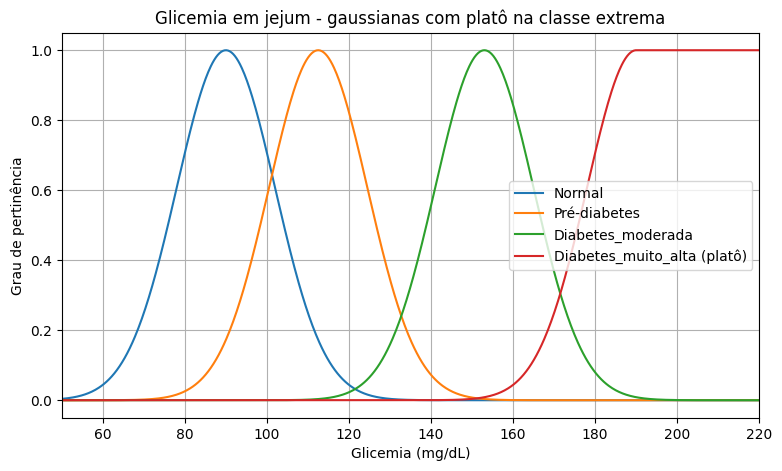

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Se estiver usando skfuzzy no Colab:
# import skfuzzy as fuzz
# def gaussmf(x, mean, sigma): return fuzz.gaussmf(x, mean, sigma)

# Aqui defino gaussmf na mão, mas a fórmula é a mesma do skfuzzy
def gaussmf(x, mean, sigma):
    return np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Universo da glicemia
x_glic = np.linspace(50, 260, 1001)
sigma_g = 12.0

# Gaussianas "normais"
# normal = gaussmf(x_glic, 90, sigma_imc)   # meio 18.5–24.9
# normal[x_glic <= 90] = 1.0

normal       = gaussmf(x_glic,  90,    sigma_g)   # centro ~90 (70–99)
pre_diabetes = gaussmf(x_glic, 112.5, sigma_g)    # 100–125
dm_moderada  = gaussmf(x_glic, 153,   sigma_g)    # 126–180

# Diabetes muito alta: gaussiana + platô a partir do ápice
dm_muito_alta = gaussmf(x_glic, 190, sigma_g)     # pico em 190
dm_muito_alta[x_glic >= 190] = 1.0               # reta = 1 para glicemias maiores

plt.figure(figsize=(9,5))
plt.plot(x_glic, normal,        label='Normal')
plt.plot(x_glic, pre_diabetes,  label='Pré-diabetes')
plt.plot(x_glic, dm_moderada,   label='Diabetes_moderada')
plt.plot(x_glic, dm_muito_alta, label='Diabetes_muito_alta (platô)')
plt.title('Glicemia em jejum - gaussianas com platô na classe extrema')
plt.xlabel('Glicemia (mg/dL)')
plt.ylabel('Grau de pertinência')
plt.ylim(-0.05, 1.05)
plt.xlim(50, 220)
plt.grid(True)
plt.legend()
plt.show()


#### IMC

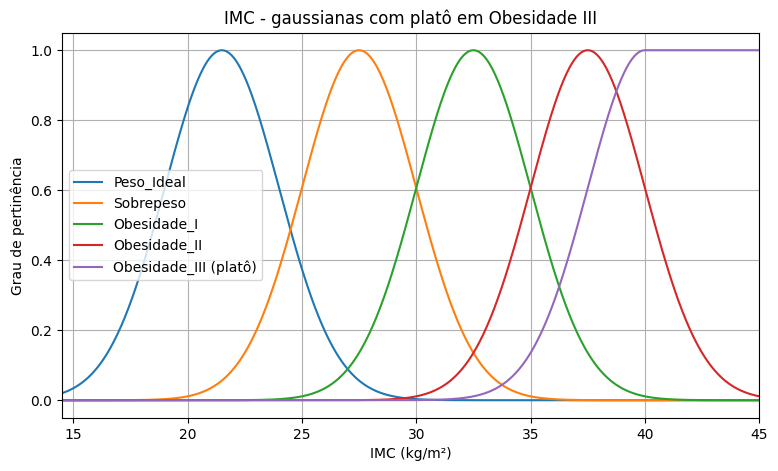

In [11]:
# Universo do IMC
x_imc = np.linspace(14.5, 55, 1001)
sigma_imc = 2.5


peso_ideal = gaussmf(x_imc, 21.5, sigma_imc)   # meio 18.5–24.9
sobrepeso  = gaussmf(x_imc, 27.5, sigma_imc)   # meio 25–29.9
obes_I     = gaussmf(x_imc, 32.5, sigma_imc)   # meio 30–34.9
obes_II    = gaussmf(x_imc, 37.5, sigma_imc)   # meio 35–39.9

# Obesidade III: pico em 40, qualquer IMC >= 40 fica com µ = 1 (platô)
obes_III = gaussmf(x_imc, 40, sigma_imc)
obes_III[x_imc >= 40] = 1.0

plt.figure(figsize=(9,5))
plt.plot(x_imc, peso_ideal, label='Peso_Ideal')
plt.plot(x_imc, sobrepeso,  label='Sobrepeso')
plt.plot(x_imc, obes_I,     label='Obesidade_I')
plt.plot(x_imc, obes_II,    label='Obesidade_II')
plt.plot(x_imc, obes_III,   label='Obesidade_III (platô)')
plt.title('IMC - gaussianas com platô em Obesidade III')
plt.xlabel('IMC (kg/m²)')
plt.ylabel('Grau de pertinência')
plt.ylim(-0.05, 1.05)
plt.xlim(14.5, 45)
plt.grid(True)
plt.legend()
plt.show()


#### Colesterol total

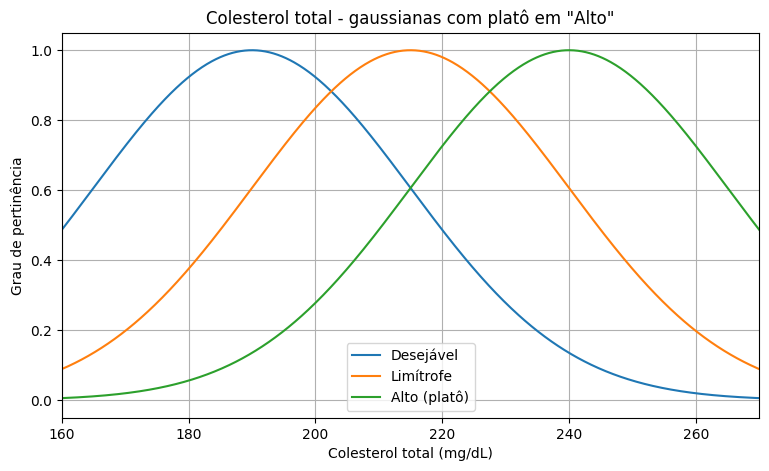

In [12]:
# Universo do colesterol
x_col = np.linspace(150, 280, 1001)
sigma_c = 25.0

# Começa com uma gaussiana de centro 190
desejavel = fuzz.gaussmf(x_col, 190, sigma_c)
# Força platô de µ=1 para valores menores que o centro
# desejavel[x_col <= 190] = 1.0

limitrofe = gaussmf(x_col, 215, sigma_c)   # 190–239

# Alto: pico em 240, qualquer C >= 240 com µ = 1
alto = gaussmf(x_col, 240, sigma_c)
# alto[x_col >= 240] = 1.0

plt.figure(figsize=(9,5))
plt.plot(x_col, desejavel, label='Desejável')
plt.plot(x_col, limitrofe, label='Limítrofe')
plt.plot(x_col, alto,      label='Alto (platô)')
plt.title('Colesterol total - gaussianas com platô em "Alto"')
plt.xlabel('Colesterol total (mg/dL)')
plt.ylabel('Grau de pertinência')
plt.ylim(-0.05, 1.05)
plt.xlim(160, 270)
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# import skfuzzy as fuzz
# from skfuzzy import control as ctrl
# import numpy as np

# # define universos
# imc = ctrl.Antecedent(np.linspace(18.5, 55, 1001), 'imc')
# glic = ctrl.Antecedent(np.linspace(70, 260, 1001), 'glic')
# col  = ctrl.Antecedent(np.linspace(120, 320, 1001), 'col')

# # em vez de fuzz.gaussmf direto, você passa os arrays que calculou
# imc['peso_ideal']    = peso_ideal
# imc['sobrepeso']     = sobrepeso
# imc['obesidade_I']   = obes_I
# imc['obesidade_II']  = obes_II
# imc['obesidade_III'] = obes_III  # já com platô

# glic['normal']             = normal
# glic['pre_diabetes']       = pre_diabetes
# glic['diabetes_moderada']  = dm_moderada
# glic['diabetes_muito_alta']= dm_muito_alta  # com platô

# col['desejavel'] = desejavel
# col['limitrofe'] = limitrofe
# col['alto']      = alto  # com platô


### 2. Utilizando a Gaussiana "natural"

Aqui assumimos que existe sim outras classes não descritas, portanto se IMC chega a 60 a gaussiana de obesidade grau 3, já decaiu, o intuito aqui é tentar interpretar que existe outras classes de obesidade que não são descritas, tipo um grau 4, e por isso o grau 3 deveria começar a decair.

## So pra nao perder

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# --------- IMC ---------
x_imc = np.linspace(14.5, 55, 1001)
sigma_imc = 2.5

peso_ideal = fuzz.gaussmf(x_imc, 21.5, sigma_imc)   # 18.5–24.9
sobrepeso  = fuzz.gaussmf(x_imc, 27.5, sigma_imc)   # 25–29.9
obes_I     = fuzz.gaussmf(x_imc, 32.5, sigma_imc)   # 30–34.9
obes_II    = fuzz.gaussmf(x_imc, 37.5, sigma_imc)   # 35–39.9

obes_III = fuzz.gaussmf(x_imc, 40, sigma_imc)       # ≥40, gauss + platô
obes_III[x_imc >= 40] = 1.0

# --------- GLICEMIA ---------
x_glic = np.linspace(50, 260, 1001)
sigma_g = 12.0

normal       = fuzz.gaussmf(x_glic,  90,    sigma_g)   # ~70–99
pre_diabetes = fuzz.gaussmf(x_glic, 112.5, sigma_g)    # 100–125
dm_moderada  = fuzz.gaussmf(x_glic, 153,   sigma_g)    # 126–180

dm_muito_alta = fuzz.gaussmf(x_glic, 190, sigma_g)     # ≥180
dm_muito_alta[x_glic >= 190] = 1.0                    # platô depois do pico

# --------- COLESTEROL ---------
x_col = np.linspace(150, 280, 1001)
sigma_c = 10.0

desejavel = fuzz.gaussmf(x_col, 190, sigma_c)
limitrofe = fuzz.gaussmf(x_col, 215, sigma_c)
alto      = fuzz.gaussmf(x_col, 240, sigma_c)
alto[x_col >= 240] = 1.0                              # ≥240 platô

# --------- RISCO (saída) ---------
x_risco = np.linspace(0, 100, 1001)
sigma_r = 8.0

baixo       = fuzz.gaussmf(x_risco,   0, sigma_r)
medio       = fuzz.gaussmf(x_risco,  25, sigma_r)
alto_risco  = fuzz.gaussmf(x_risco,  50, sigma_r)
muito_alto  = fuzz.gaussmf(x_risco,  75, sigma_r)
extremo     = fuzz.gaussmf(x_risco, 100, sigma_r)


In [ ]:
# Cria variáveis fuzzy (Antecedentes) e a saída (Consequente)
imc  = ctrl.Antecedent(x_imc,   'imc')
glic = ctrl.Antecedent(x_glic,  'glic')
col  = ctrl.Antecedent(x_col,   'col')
risco = ctrl.Consequent(x_risco, 'risco')

# Atribui os conjuntos de IMC
imc['peso_ideal']    = peso_ideal
imc['sobrepeso']     = sobrepeso
imc['obesidade_I']   = obes_I
imc['obesidade_II']  = obes_II
imc['obesidade_III'] = obes_III   # com platô

# Atribui os conjuntos de glicemia
glic['normal']              = normal
glic['pre_diabetes']        = pre_diabetes
glic['diabetes_moderada']   = dm_moderada
glic['diabetes_muito_alta'] = dm_muito_alta  # com platô

# Atribui os conjuntos de colesterol
col['desejavel'] = desejavel
col['limitrofe'] = limitrofe
col['alto']      = alto  # com platô

# Atribui os conjuntos de risco (saída)
risco['baixo']       = baixo
risco['medio']       = medio
risco['alto']        = alto_risco
risco['muito_alto']  = muito_alto
risco['extremo']     = extremo


In [ ]:
# Exemplos de regras (pegas da sua lógica/tabelas)

# 1) Baixíssimo risco
r1 = ctrl.Rule(
    imc['peso_ideal'] & glic['normal'] & col['desejavel'],
    risco['baixo']
)

# 2) Sobrepeso + pré-diabetes + colesterol limítrofe → risco médio
r2 = ctrl.Rule(
    imc['sobrepeso'] & glic['pre_diabetes'] & col['limitrofe'],
    risco['medio']
)

# 3) Obesidade I + pré-diabetes + colesterol limítrofe → risco alto
r3 = ctrl.Rule(
    imc['obesidade_I'] & glic['pre_diabetes'] & col['limitrofe'],
    risco['alto']
)

# 4) Obesidade II + DM moderada + colesterol alto → risco muito alto
r4 = ctrl.Rule(
    imc['obesidade_II'] & glic['diabetes_moderada'] & col['alto'],
    risco['muito_alto']
)

# 5) Obesidade III + DM muito alta + colesterol alto → risco extremo
r5 = ctrl.Rule(
    imc['obesidade_III'] & glic['diabetes_muito_alta'] & col['alto'],
    risco['extremo']
)


Risco fuzzy calculado: 8.30767020808638


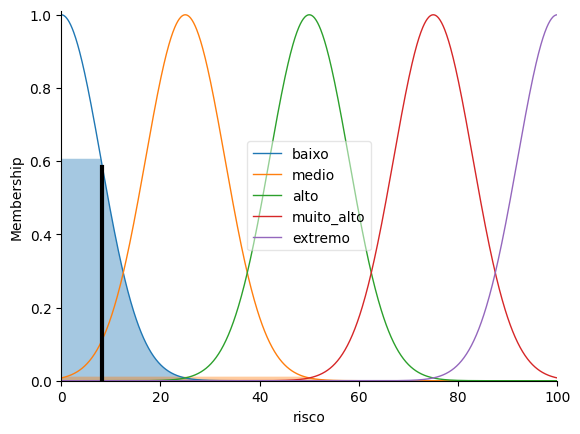

In [ ]:
# Junta as regras em um sistema
sistema_risco = ctrl.ControlSystem([r1, r2, r3, r4, r5])
simulador = ctrl.ControlSystemSimulation(sistema_risco)

# Exemplo: paciente com IMC=42, glicemia=190, colesterol=260
simulador.input['imc'] = 20
simulador.input['glic'] = 80
simulador.input['col'] = 200

# Faz a inferência
simulador.compute()

print("Risco fuzzy calculado:", simulador.output['risco'])

# (Opcional) Ver a defuzzificação no gráfico
risco.view(sim=simulador)
plt.show()


In [ ]:
# só ideia, não código final
map_imc = ['peso_ideal', 'sobrepeso', 'obesidade_I', 'obesidade_II', 'obesidade_III']
map_g  = ['normal', 'pre_diabetes', 'diabetes_moderada', 'diabetes_muito_alta']
map_c  = ['desejavel', 'limitrofe', 'alto']
map_r  = [['baixo', ...], ...]  # sua tabela de risco por célula


---
# Referências

Algumas outras referências foram usadas também, isso para poder ajudar nas regras e nos conjuntos